In [ ]:
%pip install realspace-tb

In [1]:
import os
import sys

# 1. Get the folder where the notebook is (Folder 2)
notebook_dir = os.getcwd()

# 2. Go up one level and then into Folder 1
realspace_tb_path = os.path.abspath(os.path.join(notebook_dir, '..'))

# 3. Add to sys.path so you can import
if realspace_tb_path not in sys.path:
    sys.path.append(realspace_tb_path)

import realspace_tb as tb
import realspace_tb.orbitronics_2d as orb
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

c:\Users\arist\anaconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Armchair ribbon

In [2]:
Lx,Ly = 17, 10
scale = 0.0992
t_hop = -scale
field_amplitude=orb.RampedACFieldAmplitude(E0=5e-3, omega=2*scale, T_ramp=40/scale, direction=np.array([0, 1]))
geo_ac = orb.HoneycombLatticeGeometry(
   Lx=Lx, 
   Ly=Ly, 
   pbc_x=False, 
   pbc_y=True,
)


H_ac = orb.LinearFieldHamiltonianPeierls(geo_ac, t_hop, field_amplitude)

In [3]:
#_, plaq_pos1 = geo_ac.plaquettes
plaq_ind, plaq_pos, plaq_xstep, plaq_ystep = geo_ac.plaquettes

In [5]:
plaq_ystep

np.float64(1.5)

In [10]:
np.diff(np.unique(plaq_pos2[:,0]))

array([0.8660254, 0.8660254, 0.8660254, 0.8660254, 0.8660254, 0.8660254,
       0.8660254, 0.8660254, 0.8660254, 0.8660254, 0.8660254, 0.8660254,
       0.8660254, 0.8660254])

In [ ]:
import numpy as np

array1 = np.array([[3, 1], [-3, -5]])
array2 = np.array([0.5, -1])

# Method 1: Reshape using np.newaxis (Cleanest)
array3 = array1 * array2[:, np.newaxis]

# Method 2: Reshape using .reshape()
# array3 = array1 * array2.reshape(-1, 1)

print(array3)

In [ ]:
plaq_ind, plaq_pos = geo_ac.plaquettes
plaq_pos[:15]

In [3]:
beta = float("inf")
rho = H_ac.thermal_state_density_matrix(fermi_level=0.0, beta=float("inf"))
vort = orb.observables.VorticityObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vortflux = orb.observables.VortFluxObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vortsrc = orb.observables.VortSourceObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vort_pol = orb.observables.VortPolObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
animation = orb.observables.LatticeFrameObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vectorvortflux = orb.observables.VectorVortFluxObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
#tb.RK4NeumannSolver().evolve(rho, H_ac, dt=0.005/scale, total_time=field_amplitude.T_ramp + 40/scale, observables=[animation, orb_pol], tau=float("inf"))
tb.RK4NeumannSolver().evolve(rho, H_ac, dt=0.005/scale, total_time=field_amplitude.T_ramp + 40/scale, observables=[vort, vortflux, vortsrc, animation, vort_pol, vectorvortflux], tau=float("inf"))

Calculating eigenstates at t=0...


  0%|          | 0/16000 [00:00<?, ?it/s]

100%|██████████| 16000/16000 [04:13<00:00, 63.10it/s]


In [11]:
vectorvortflux._y_dist_matrix[0]

array([ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5,  1.5,  1.5,
        1.5,  1.5,  1.5,  1.5,  3. ,  3. ,  3. ,  3. ,  3. ,  3. ,  3. ,
        3. ,  4.5,  4.5,  4.5,  4.5,  4.5,  4.5,  4.5,  6. ,  6. ,  6. ,
        6. ,  6. ,  6. ,  6. ,  6. ,  7.5,  7.5,  7.5,  7.5,  7.5,  7.5,
        7.5, -6. , -6. , -6. , -6. , -6. , -6. , -6. , -6. , -4.5, -4.5,
       -4.5, -4.5, -4.5, -4.5, -4.5, -3. , -3. , -3. , -3. , -3. , -3. ,
       -3. , -3. , -1.5, -1.5, -1.5, -1.5, -1.5, -1.5, -1.5])

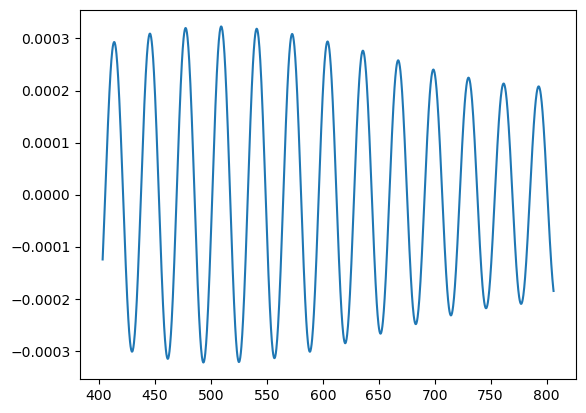

In [7]:
import matplotlib.pyplot as plt
plt.plot(vectorvortflux.measurement_times, vectorvortflux.values[:,0])

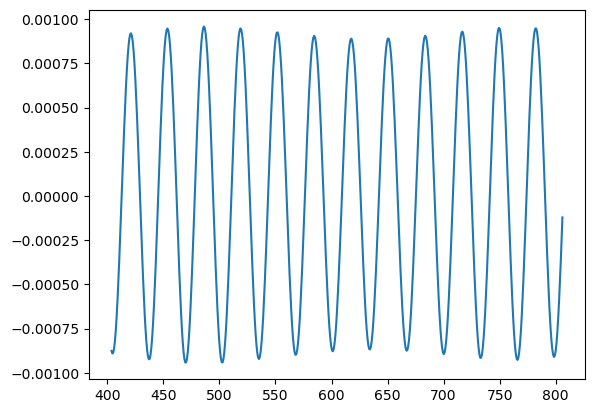

In [12]:
import matplotlib.pyplot as plt
plt.plot(vort_pol.measurement_times, vort_pol.values[:,0])

In [ ]:
measurement_times = []
sites = [3,23,44,56]
dotvorts = []
divvortfluxs = []
vortsources = []
right_terms = []
for m, time in enumerate(vort.measurement_times):
    dotvort = []
    divvortflux = []
    vortsource = []
    right_term = []
    if (m >= 2) and (m <= len(vort.measurement_times)-3):
        measurement_times.append(time)
        dotvort_at_m = (-vort.values[m+2]+8*vort.values[m+1]-8*vort.values[m-1]+vort.values[m-2])/(12*0.005/scale*5)
        divvortflux_at_m = np.sum(vortflux.values[m],axis=1)
        vortsource_at_m = vortsrc.values[m]
        for st in sites:
            dotvort_at_m_at_st = dotvort_at_m[st]
            divvortflux_at_m_at_st = divvortflux_at_m[st]
            vortsource_at_m_at_st = vortsource_at_m[st]
            dotvort.append(dotvort_at_m_at_st)
            divvortflux.append(divvortflux_at_m_at_st)
            vortsource.append(vortsource_at_m_at_st)
            right_term.append(-divvortflux_at_m_at_st+vortsource_at_m_at_st)
        dotvorts.append(dotvort)
        divvortfluxs.append(divvortflux)
        vortsources.append(vortsource)
        right_terms.append(right_term)
measurement_times = np.array(measurement_times)
dotvorts = np.array(dotvorts)
divvortfluxs = np.array(divvortfluxs)
vortsources = np.array(vortsources)
right_terms = np.array(right_terms)

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
})
scale_t = 0.01
scale1 = 10000.0
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(10, 8))

axes[0,0].plot(measurement_times[::4]*scale_t, dotvorts[::4,0]*scale1, linestyle='--', marker='o', markersize=4, label=r'$\partial_{t}\langle\hat{\omega}_{P_{i}}\rangle$')
axes[0,0].plot(measurement_times[::4]*scale_t, divvortfluxs[::4,0]*scale1, linestyle='None', marker='^', markersize=3, label=r'$\sum_{P}\langle\hat{\Omega}_{P_{i}\rightarrow P}\rangle$')
axes[0,0].plot(measurement_times[::4]*scale_t, vortsources[::4,0]*scale1, linestyle='None',marker='s', markersize=3,label='_nolegend_')
axes[0,0].plot(measurement_times[::4]*scale_t, right_terms[::4,0]*scale1, linestyle='None',marker='x',markersize=3,label='_nolegend_')
axes[0,0].set_ylabel(r"Vortex rate [a.u.]")
axes[0,0].text(0.05, 1.02, r"$\times 10^{-4}$", transform=axes[0,0].transAxes, ha='right',fontsize=16)
axes[0,0].set_title("a) Plaquette 3")
axes[0,0].legend(loc='lower right',bbox_to_anchor=(0.9, 0.0), ncol=2,columnspacing=0.3,handletextpad=0.5,handlelength=1.5)

axes[0,1].plot(measurement_times[::4]*scale_t, dotvorts[::4,1]*scale1, linestyle='--', marker='o', markersize=4, label=r'$\partial_{t}\langle\hat{\omega}_{P_{i}}\rangle$')
axes[0,1].plot(measurement_times[::4]*scale_t, divvortfluxs[::4,1]*scale1, linestyle='None', marker='^', markersize=3, label=r'$\sum_{P}\langle\hat{\Omega}_{P_{i}\rightarrow P}\rangle$')
axes[0,1].plot(measurement_times[::4]*scale_t, vortsources[::4,1]*scale1, linestyle='None',marker='s', markersize=3,label=r'$\langle\hat{\Omega}_{f,P_{i}}\rangle$')
axes[0,1].plot(measurement_times[::4]*scale_t, right_terms[::4,1]*scale1, linestyle='None',marker='x',markersize=3,label='_nolegend_')
axes[0,1].set_title("b) Plaquette 23")
axes[0,1].text(0.05, 1.02, r"$\times 10^{-4}$", transform=axes[0,1].transAxes, ha='right',fontsize=16)

axes[1,0].plot(measurement_times[::4]*scale_t, dotvorts[::4,2]*scale1, linestyle='--', marker='o', markersize=4,label=r'$\partial_{t}\langle\hat{\omega}_{P_{i}}\rangle$')
axes[1,0].plot(measurement_times[::4]*scale_t, divvortfluxs[::4,2]*scale1, linestyle='None', marker='^', markersize=3,label=r'$\langle\hat{\Omega}_{P_{i}\rightarrow P}\rangle$')
axes[1,0].plot(measurement_times[::4]*scale_t, vortsources[::4,2]*scale1, linestyle='None',marker='s', markersize=3,label=r'$\langle\hat{\Omega}_{f,P_{i}}\rangle$')
axes[1,0].plot(measurement_times[::4]*scale_t, right_terms[::4,2]*scale1, linestyle='None',marker='x',markersize=3,label='_nolegend_')
axes[1,0].text(0.05, 1.02, r"$\times 10^{-4}$", transform=axes[1,0].transAxes, ha='right',fontsize=16)
axes[1,0].set_xlabel(r"$t$ $[\hbar/E_{h}]$")
axes[1,0].set_title("c) Plaquette 44")
axes[1,0].text(1.05, -0.09, r"$\times 10^{2}$", transform=axes[1,0].transAxes,ha='right',va='top',fontsize=16)
axes[1,0].set_ylabel(r"Vortex rate [a.u.]")

scale2 = 10**(17)
axes[1,1].plot(measurement_times[::4]*scale_t, dotvorts[::4,3]*scale2, linestyle='--', marker='o', markersize=4,label='_nolegend_')
axes[1,1].plot(measurement_times[::4]*scale_t, divvortfluxs[::4,3]*scale2, linestyle='None', marker='^', markersize=3,label='_nolegend_')
axes[1,1].plot(measurement_times[::4]*scale_t, vortsources[::4,3]*scale2, linestyle='None',marker='s', markersize=3,label=r'$\langle\hat{\Omega}_{f,P_{i}}\rangle$')
axes[1,1].plot(measurement_times[::4]*scale_t, right_terms[::4,3]*scale2, linestyle='None',marker='x',markersize=3,label=r'$\langle\hat{\Omega}_{f,P_{i}}\rangle-\sum_{P}\langle\hat{\Omega}_{P_{i}\rightarrow P}\rangle$')
axes[1,1].set_xlabel(r"$t$ $[\hbar/E_{h}]$")
axes[1,1].text(1.05, -0.09, r"$\times 10^{2}$", transform=axes[1,1].transAxes,ha='right',va='top',fontsize=16)
axes[1,1].text(0.05, 1.02, r"$\times 10^{-17}$", transform=axes[1,1].transAxes, ha='right',fontsize=16)
axes[1,1].legend(loc='upper left', ncol=2,columnspacing=0.3,handletextpad=0.5,handlelength=0.75)
axes[1,1].set_title("d) Plaquette 56")
#axes[1,1].set_ylabel(r"$\times 10^{-17}$")

plt.tight_layout()
plt.savefig(r"C:\Users\arist\Documents\Studium (Dr.rer.nat)\Paper_to_publish\Paper2_a_vorticity_framework_for_origin-independent_orbital_transport\cont_eq_terms.pdf", bbox_inches="tight")

In [ ]:
electric_field_vectors = [field_amplitude.at_time(t) * field_amplitude.direction for t in animation.measurement_times]
orb.save_simulation_animation(animation, "zz.mp4", 
                              electric_field_vectors=electric_field_vectors,
                              field_arrow_label="$\\vec E(t)$",
                              field_arrow_color="#14B8A6",
                              )

In [ ]:
# not for 29, but 27 and 31

# for 12, 11
# not for strong damping
# Ly dependent?!
# only for 1.98 < omega and annoying horizintal modes appear at 2.5. So

In [ ]:
# plot the currents: this shows how the currents are stronger in the center
max_orb_pol = np.argmax(orb_pol.values[:, 0])
plt.plot(np.abs(animation.values["currents"][max_orb_pol-1]))
print(f"Maximum orbital polarization at time {orb_pol.measurement_times[max_orb_pol]:.2f} with value {orb_pol.values[max_orb_pol, 0]:.4f}")

In [ ]:
from realspace_tb.orbitronics_2d.plot_utils import PlotConfig
config = PlotConfig(
    show_flow_arrows=True,           # Removes bond currents
    show_oam_indicators=True,        # Removes curl/vorticity scatter
    show_oam_direction_arrows=True,  # Removes curved arrows
    colorbar_site_occupation_fontsize=18,
    colorbar_site_occupation_textsize=14,
    colorbar_oam_fontsize=18,
    colorbar_oam_textsize=14,
    frame_texts=[""] * len(animation.measurement_times)
)

fig, ax = orb.show_simulation_frame(
    animation,
    63,
    config=config,
    #frame_texts=[""]* len(animation.measurement_times),
    show=False, # to use savefig
)

geom = animation.geometry
positions = geom.site_positions
centers = geom.plaquettes[1]
# Sort: Sweep from bottom to top (Y), then left to right (X)
# We round Y to 1 decimal place to align the zig-zagging hexagons into rows
centers_sorted = sorted(centers, key=lambda c: (round(c[1], 1), c[0]))
#print(centers)
target_indices = [3,23,44,56]
for idx in target_indices:
    if idx < len(centers_sorted):
        cx, cy = centers_sorted[idx]
        ax.plot(cx, cy, 'x', markersize=32, color='green',zorder=10) # Red dot
        ax.text(cx, cy + 0.35, str(idx), color='green', fontsize=16, 
                fontweight='bold', ha='center', va='bottom', zorder=11)
#plt.show()
plt.savefig(r"C:\Users\arist\Documents\Studium (Dr.rer.nat)\Paper_to_publish\Paper2_a_vorticity_framework_for_origin-independent_orbital_transport\snapshot_TB.pdf", bbox_inches="tight")

# Zigzag Nanoribbon

In [ ]:
field_amplitude=orb.RampedACFieldAmplitude(E0=1e-3, omega=0.5, T_ramp=40, direction=np.array([1, 0]))
geo_zz = orb.HoneycombLatticeGeometry(
    Lx=10, 
    Ly=13, 
    pbc_x=True, 
    pbc_y=False,
)

H_zz = orb.LinearFieldHamiltonianPeierls(geo_zz, field_amplitude)
rho = H_zz.ground_state_density_matrix(fermi_level=0.0)
animation = orb.observables.LatticeFrameObservable(H_zz.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude.T_ramp), hamiltonian=H_zz)
orb_pol = orb.observables.OrbitalPolarizationObservable(H_zz.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude.T_ramp), hamiltonian=H_zz)
tb.RK45Solver().evolve(rho, H_zz, dt=0.01, total_time=field_amplitude.T_ramp + 50, observables=[animation, orb_pol], tau=20)

In [ ]:
max_orb_pol = np.argmax(orb_pol.values[:, 1])
print(f"Maximum orbital polarization at time {orb_pol.measurement_times[max_orb_pol]:.2f} with value {orb_pol.values[max_orb_pol, 1]:.4f}")

orb.show_simulation_frame(
    animation,
    max_orb_pol+15,
    show_oam_direction_arrows=True,
    frame_texts=[""]* len(animation.measurement_times),
    oam_arrow_threshold=0.0001,
    show=False, # to use savefig
)

plt.savefig("zz_max_orb_pol.pdf", bbox_inches="tight")

In [ ]:
electric_field_vectors = [field_amplitude.at_time(t) * field_amplitude.direction for t in animation.measurement_times]
orb.save_simulation_animation(animation, "zz.mp4", 
                              electric_field_vectors=electric_field_vectors,
                              field_arrow_label="$\\vec E(t)$",
                              field_arrow_color="#14B8A6",
                              field_arrow_type="horizontal",
                              )

In [ ]:
def save_findings(animation, zz_ribbon, dirname):
    # make a directory at dirname
    findings_dir = Path(dirname)
    findings_dir.mkdir(exist_ok=False)

    pickle_path = findings_dir / "geometry.pickle"
    with pickle_path.open("b+w") as f:
        pickle.dump(zz_ribbon, f)

    markdown_path = findings_dir / "stats.md"
    with markdown_path.open("w") as md:
        md.writelines([f"---\n{key}: {value}\n\n" for key, value in zz_ribbon.field_amplitude.__dict__.items()])
        md.writelines([f"---\n{key}: {value}\n\n" for key, value in zz_ribbon.__dict__.items()])
        
    anim_path = findings_dir / "animation.mp4"
    orb.save_simulation_animation(animation, anim_path)

In [ ]:
save_findings(animation, H_ac, "niceSeparationVanHove3")